In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [140]:
data = pd.read_csv('coffee_shop_sales.csv')

In [147]:
data.isna().sum()

transaction_id          0
timestamp               0
store_id                0
city                    0
country                 0
store_type              0
product_category        0
product_name            0
unit_price              0
quantity                0
discount_applied        0
payment_method          0
customer_id             0
customer_age_group      0
customer_gender         0
loyalty_member          0
weather_condition       0
temperature_c         978
holiday_name            0
total_amount            0
hour                    0
dayofweek               0
month                   0
date                    0
dtype: int64

In [146]:
#Handling missing values:
data['holiday_name'] = data['holiday_name'].fillna('no_holiday')
data['customer_age_group'] = data['customer_age_group'].fillna('unknown')
data['customer_gender'] = data['customer_gender'].fillna('unknown')
data['weather_condition'] = data['weather_condition'].fillna('unknown')

In [144]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

data['hour'] = data['timestamp'].dt.hour
data['dayofweek'] = data['timestamp'].dt.dayofweek
data['month'] = data['timestamp'].dt.month
data['date'] = data['timestamp'].dt.date

Section 1: Descriptive Analysis:

 SECTION 1:TIME-DRIVEN REVENUE OPTIMIZATION

In [ ]:
revenue_by_hour = data.groupby("hour")["total_amount"].sum()

revenue_by_hour.plot(kind="line", marker='o')
plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
data["day"] = pd.Categorical(data["day"], categories=day_order, ordered=True)
revenue_by_day = data.groupby("day")["total_amount"].sum()

revenue_by_day.plot(kind="line", marker='o')
plt.title("Revenue by day")
plt.xlabel("day")
plt.ylabel("Revenue")
plt.show()

In [ ]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
data["month"] = pd.Categorical(data["month"], categories=month_order, ordered=True)

revenue_by_month = data.groupby("month")["total_amount"].sum()
revenue_by_month.plot(kind="line", marker='o')
plt.title("Revenue by month")
plt.xlabel("month")
plt.ylabel("Revenue")
plt.show()

In [ ]:
revenue_hour_product = data.groupby(["hour", "product_category"])["total_amount"].sum().unstack()

revenue_hour_product.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Revenue by Hour and Product Category")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.legend(title="Product Category")
plt.show()

In [ ]:
revenue_day_product = data.groupby(["day", "product_category"])["total_amount"].sum().unstack()

revenue_day_product.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Revenue by Day and Product Category")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.legend(title="Product Category")
plt.show()

In [ ]:
revenue_month_product = data.groupby(["month", "product_category"])["total_amount"].sum().unstack()

revenue_month_product.plot(kind="bar", stacked=True, figsize=(14,9))

plt.title("Revenue by month and Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Product Category")
plt.show()

In [ ]:
pivot_store = data.pivot_table(
    values="total_amount",
    index="hour",
    columns="store_type",
    aggfunc="sum"
)

pivot_store.plot(figsize=(12,6))

plt.title("Revenue by Hour and Store Type")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.legend(title="Store Type")
plt.show()


In [ ]:
data["discount_label"] = data["discount_applied"].map({False: "No Discount", True: "Discount Applied"})
pivot_discount = data.pivot_table(
    values="total_amount",
    index="hour",
    columns="discount_label",
    aggfunc="sum"
)
pivot_discount.plot(figsize=(12,6))
plt.title("Revenue by Hour and Discount Status")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.legend(title="Discount Status")
plt.show()

Section 2 LOCATION & MARKET PERFORMANCE:

In [ ]:
revenue_by_city = data.groupby("city")["total_amount"].sum().sort_values(ascending=False)
revenue_by_city.plot(kind="bar", figsize=(12,6))
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

In [ ]:

revenue_by_country = data.groupby("country")["total_amount"].sum().sort_values(ascending=False)
revenue_by_country.plot(kind="bar", figsize=(12,6))
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

In [ ]:
pivot_city_store = data.pivot_table(
    values="total_amount",
    index="city",
    columns="store_type",
    aggfunc="sum"
)
pivot_city_store.plot(kind="bar", figsize=(12,6))
plt.title("Revenue by City and Store Type")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.legend(title="Store Type")
plt.show()

In [ ]:
pivot_city_product = data.pivot_table(
    values="total_amount",
    index="city",
    columns="product_category",
    aggfunc="sum"
)
pivot_city_product = pivot_city_product.sort_values(by="Coffee", ascending=False)
sns.heatmap(pivot_city_product, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Revenue by City and Product Category")
plt.xlabel("Product Category")
plt.ylabel("City")
plt.show()

In [ ]:
pivot_percentage = pivot_city_product.div(pivot_city_product.sum(axis=1), axis=0)
pivot_percentage = pivot_percentage.sort_values(by="Coffee", ascending=False)

sns.heatmap(pivot_percentage, annot=True, fmt=".1%", cmap="coolwarm")

plt.title("Product Preference by City (%)")
plt.show()

In [ ]:
pivot_city_product.plot(kind="bar", stacked=True, figsize=(14,9))

SECTION 3 : PRODUCT & MENU OPTIMIZATION

In [ ]:
top_products = data.groupby("product_name")["total_amount"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar", figsize=(12,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
product_analysis = data.groupby("product_category").agg({
    "quantity": "sum",
    "total_amount": "sum"
})

product_analysis.plot(kind="bar", figsize=(8,5))

plt.title("Quantity vs Revenue by Product Category")
plt.ylabel("Value")
plt.show()

In [ ]:
avg_discount_product = data.groupby(["product_category", "discount_applied"])["total_amount"].mean().unstack()
avg_discount_product.plot(kind="bar", figsize=(8,5))

plt.title("Average Revenue per Transaction by Product and Discount")
plt.ylabel("Average Revenue")
plt.show()


In [ ]:
qty_discount_product = data.groupby(["product_category", "discount_applied"])["quantity"].mean().unstack()
qty_discount_product.plot(kind="bar", figsize=(10,8))

plt.title("Average Quantity per Transaction by Product and Discount")
plt.ylabel("Average Quantity")
plt.show()

In [ ]:
segment_discount = data.groupby(
    ["customer_age_group", "discount_applied"]
)["total_amount"].mean().unstack()

segment_discount.plot(kind="bar", figsize=(10,5))

plt.title("Discount Effect by Age Group")
plt.show()

Section 4 — Customer Behavior:

In [ ]:
loyalty_revenue = data.groupby("loyalty_member")["total_amount"].mean()
loyalty_revenue.plot(kind="bar", figsize=(5,3))
plt.title("Average Revenue per Transaction by Loyalty Membership")
plt.xticks([0,1], ["Non-Loyal", "Loyal"], rotation=0)
plt.xlabel("Loyalty Member")
plt.ylabel("Average Revenue")

In [ ]:
age_revenue = data.groupby("customer_age_group")["total_amount"].mean().sort_values()
age_revenue.plot(kind="bar", figsize=(8,5))
plt.title("Average Revenue per Transaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Revenue")

In [ ]:
gender_rev = data.groupby("customer_gender")["total_amount"].mean()

gender_rev.plot(kind="bar")

plt.title("Average Revenue by Gender")
plt.ylabel("Average Revenue")
plt.show()

In [ ]:
pivot_age_loyalty_revenue = data.pivot_table(
    values="total_amount",
    index="customer_age_group",
    columns="loyalty_member",
    aggfunc="mean"
)
pivot_age_loyalty_revenue.plot(kind="bar", figsize=(10,6))
plt.title("Average Revenue by Age Group and Loyalty Membership")    
plt.xlabel("Age Group")
plt.ylabel("Average Revenue")
plt.show()

In [ ]:
age_discount = data.groupby(["customer_age_group", "discount_applied"])["total_amount"].mean().unstack()

age_discount.plot(kind="bar", figsize=(12,10))

plt.title("Discount Impact by Age Group")
plt.ylabel("Average Revenue")
plt.show()

In [ ]:
age_loyalty = data.groupby("customer_age_group")["loyalty_member"].mean()

age_loyalty.plot(kind="bar", figsize=(8,5))

plt.title("Loyalty Rate by Age Group")
plt.ylabel("Proportion of Loyal Customers")
plt.show()

SECTION 5 — WEATHER IMPACT ANALYSIS

In [ ]:
weather_rev = data.groupby("weather_condition")["total_amount"].mean().sort_values()

weather_rev.plot(kind="bar", figsize=(8,5))

plt.title("Average Revenue by Weather Condition")
plt.ylabel("Average Revenue")
plt.show()

In [ ]:
sns.scatterplot(data =data , x="temperature_c", y="total_amount")
plt.title("Revenue vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Revenue")
plt.show()

In [ ]:
pivot_weather_product = data.pivot_table(
    values="total_amount",
    index="weather_condition",
    columns="product_category",
    aggfunc="mean"
)

pivot_weather_product.plot(kind="bar", figsize=(12,8))

plt.title("Product Performance by Weather")
plt.ylabel("Average Revenue")
plt.show()

In [ ]:
data["temp_bin"] = pd.cut(data["temperature_c"], bins=5)

temp_rev = data.groupby("temp_bin")["total_amount"].mean()

temp_rev.plot(kind="line", marker="o")
plt.title("Average Revenue by Temperature Range")
plt.show()

In [ ]:
pivot_weather_city = data.pivot_table(
    values="total_amount",
    index="weather_condition",
    columns="city",
    aggfunc="mean"
)

sns.heatmap(pivot_weather_city,annot=True, cmap="coolwarm")

plt.title("Weather Impact by City")
plt.show()

SECTION 6 — HOLIDAY & EVENT ANALYSIS

In [ ]:
data["is_holiday"] = data["holiday_name"].notna()
holiday_vs_normal = data.groupby("is_holiday")["total_amount"].mean()

holiday_vs_normal.plot(kind="bar")

plt.title("Holiday vs Non-Holiday Spending")
plt.xticks([0,1], ["Non-Holiday", "Holiday"], rotation=0)
plt.ylabel("Average Revenue")
plt.show()

In [ ]:
holiday_rev = data.groupby("holiday_name")["total_amount"].mean().dropna().sort_values()

holiday_rev.plot(kind="bar", figsize=(10,5))

plt.title("Average Revenue by Holiday")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
pivot_holiday_product = data.pivot_table(
    values="total_amount",
    index="holiday_name",
    columns="product_category",
    aggfunc="mean"
)
pivot_holiday_product.plot(kind="bar", figsize=(12,8))
plt.title("Revenue by Holiday and Product Category")
plt.ylabel("Average Revenue")
plt.show()

In [ ]:
pivot_holiday_city = data.pivot_table(
    values="total_amount",
    index="holiday_name",
    columns="city",
    aggfunc="mean"
)

pivot_holiday_city.plot(kind="bar", figsize=(12,6))
plt.title("Holiday Impact by City")
plt.show()

Section 2: Predictive Analysis

CUSTOMER SEGMENTATION and PRODUCT SEGMENTATION

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [152]:
#Convert transaction data → demand data

hourly_df = data.groupby(['store_id', 'date', 'hour']).agg({
    'transaction_id': 'count',
    'temperature_c': 'mean',
    'weather_condition': lambda x: x.mode()[0]
}).reset_index()

hourly_df = hourly_df.rename(columns={
    'transaction_id': 'transactions'
})


In [154]:
hourly_df['datetime'] = pd.to_datetime(hourly_df['date']) + pd.to_timedelta(hourly_df['hour'], unit='h')

hourly_df['dayofweek'] = hourly_df['datetime'].dt.dayofweek
hourly_df['month'] = hourly_df['datetime'].dt.month
hourly_df['is_weekend'] = hourly_df['dayofweek'].isin([5, 6]).astype(int)

In [155]:
hourly_df = hourly_df.sort_values(['store_id', 'datetime'])

In [156]:
hourly_df['lag_1'] = hourly_df.groupby('store_id')['transactions'].shift(1)
hourly_df['lag_24'] = hourly_df.groupby('store_id')['transactions'].shift(24)


In [157]:
hourly_df = pd.get_dummies(hourly_df, columns=['weather_condition'], drop_first=True)

In [158]:
features = [
    'hour',
    'dayofweek',
    'month',
    'is_weekend',
    'temperature_c',
    'lag_1',
    'lag_24'
] + [col for col in hourly_df.columns if col.startswith('weather_condition_')]

X = hourly_df[features]
y = hourly_df['transactions']

In [159]:
split = int(len(hourly_df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [160]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [161]:
y_pred = model.predict(X_test)

In [162]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.08367909491062164
RMSE: 0.2133630532807034


<Axes: >

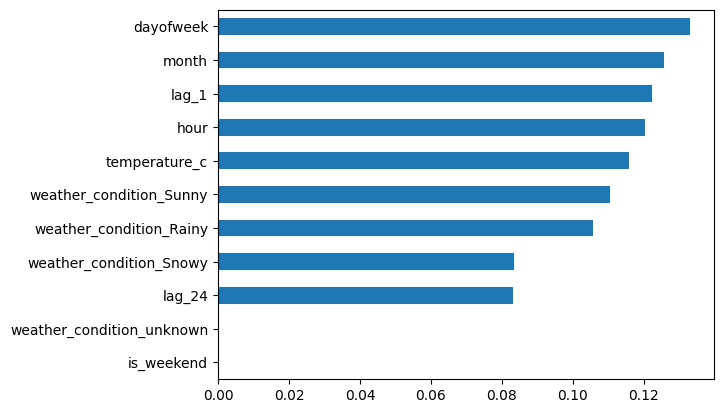

In [163]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')